# npE Plotting and Analysis Tools

In [1]:
project_path = '~/projects/npe'

## Plot Dephasing

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import lal

npe_dir = os.path.abspath(os.path.expanduser(os.path.join(project_path, 'npe')))
if npe_dir not in sys.path:
    sys.path.append(npe_dir)

from waveform_analysis import VAE

MSUN_KM = lal.MSUN_SI * lal.G_SI / lal.C_SI ** 2 / 1e3
MSUN_S  = MSUN_KM / lal.C_SI * 1e3

/tmp/ipykernel_762811/4075395363.py:6: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [3]:
#import locale

#_ = locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')

In [4]:
from workflow import initialize

# Import PyTorch network
def import_network(network_path, base_path=project_path):

    network_fullpath = os.path.expanduser(os.path.join(base_path, network_path))

    device = torch.device('cpu')
    model_kwargs = dict(depth=4, width=512, data_dim=640, grid_dim=2, freeze_shape=True)
    optimizer_kwargs = dict(lr=1e-4, weight_decay=1e-4)
    scheduler_kwargs = dict(gamma=0.9)
    
    model_type = VAE
    optimizer_type = torch.optim.AdamW
    scheduler_type = torch.optim.lr_scheduler.ExponentialLR

    model, optimizer, scheduler = initialize(
                                    model_type, optimizer_type, scheduler_type,
                                    model_kwargs=model_kwargs,
                                    optimizer_kwargs=optimizer_kwargs,
                                    scheduler_kwargs=scheduler_kwargs, device=device)
    
    state_dict = torch.load(network_fullpath, map_location=device, weights_only=True)

    model = model_type(**model_kwargs).to(device)
    optimizer = optimizer_type(model.parameters(), **optimizer_kwargs)
    scheduler = scheduler_type(optimizer, **scheduler_kwargs)

    model.load_state_dict(state_dict['model'])
    if optimizer is not None: optimizer.load_state_dict(state_dict['optimizer'])
    if scheduler is not None: scheduler.load_state_dict(state_dict['scheduler'])

    model.eval()
    model.train(False)

    return model, device, optimizer, scheduler

In [5]:
def plot_dephasing(network_path, base_path=project_path, network_type='BBH', sample_zmags=False, show_plot=True, title=''):
    if network_type not in ['BBH', 'BNS']:
        print('Error: Unsupported network_type. Defaulting to network_type=\'BBH\'')
        network_type = 'BBH'
    # Import specified network
    #model, device = import_network(network_path, base_path)
    model, device, _, _ = import_network(network_path, base_path)

    # Get dephasing values from shape function
    if network_type == 'BNS':
        f_min = 0.004
        f_max = 0.18
        f_num = 640

        m_min = 0.6
        m_max = 3.0
    elif network_type == 'BBH':
        f_min = 0.0004
        f_max = 0.018
        f_num = 640

        m_min = 5.0
        m_max = 30.0
    else:
        print('Error')
        return False

    #z_mag = np.linspace(0, 1, 100)
    #z_mag = 0.5
    z_ang_arr = np.linspace(0, 2*np.pi, 360)

    if sample_zmags:
        z1_arr = np.array([np.random.uniform(0,1) * np.cos(z_ang) for z_ang in z_ang_arr])
        z2_arr = np.array([np.random.uniform(0,1) * np.sin(z_ang) for z_ang in z_ang_arr])
    else:
        z1_arr = np.array([0.5 * np.cos(z_ang) for z_ang in z_ang_arr])
        z2_arr = np.array([0.5 * np.sin(z_ang) for z_ang in z_ang_arr])

    norm_fac = 1.

    print('z1: ', z1_arr.shape)
    print('z2: ', z2_arr.shape)

    # Loop the below over all sampled z_theta values
    for z1, z2 in zip(z1_arr, z2_arr):
        z_mag = np.sqrt(z1**2 + z2**2)
        ## TODO: Finish adapting all of this
        f_min_geom = f_min*(2*m_min*MSUN_S)
        f_max_geom = f_max*(2*m_max*MSUN_S)
        # TODO: Should we provide unitless or geometric frequencies?
        freqs = np.linspace(f_min, f_max, f_num)
        geom_freqs = np.linspace(f_min_geom, f_max_geom, f_num)
        model_loggeom_freqs = np.linspace(np.log10(f_min_geom), np.log10(f_max_geom), f_num)
        geom_freqs_cutoff = np.exp(model_loggeom_freqs[-1])
        mask_low = geom_freqs <= 0
        mask_high = geom_freqs > geom_freqs_cutoff
        mask_mid = ~(mask_low|mask_high)
        #loggeom_freqs = np.log10(np.append(geom_freqs[mask_mid], geom_freqs_cutoff))
        loggeom_freqs = np.log10(np.append(geom_freqs[mask_mid], geom_freqs_cutoff))
        loggeom_freq_range = model_loggeom_freqs[-1] - model_loggeom_freqs[0]
        xin = (loggeom_freqs - model_loggeom_freqs[0]) / loggeom_freq_range
        xin = torch.tensor(xin, dtype=torch.float32, device=device).view(1, -1)

        # TODO: What values of z and cond do we need?
        z = torch.tensor([z1/z_mag, z2/z_mag], dtype=torch.float32, device=device).view(1, -1)
        #cond = self.gw_params_to_vae_labels(mass_1, mass_2, chi_1, chi_2) # returns: [Mc, eta, chi_sym, chi_asym]
        cond = [25, 1, 0, 0]
        cond = torch.tensor(cond, dtype=torch.float32, device=device).view(1, -1)
        #print('z: ', z.shape)
        #print('cond: ', cond.shape)

        Sout, dSout = model.extended_decoder(z, cond, xin)

        #print('Sout: ', Sout.shape)

        # TODO: Finish adapting all of this
        xout, dext = Sout.view(-1).cpu().detach().numpy().flatten(), dSout.item()

        #print('xout: ', xout.shape)
        #print('dext: ', dext)
        #print('Sout: ', Sout.shape)

        Smag = np.sqrt(np.sum([xout_val**2 for xout_val in xout]))
        #print('Smag: ', Smag)

        phases_mod = np.zeros_like(geom_freqs)
        phases_mod[mask_mid] = xout[:-1]
        phases_mod[mask_high] = xout[-1] + dext / loggeom_freq_range / np.log(10) * (geom_freqs[mask_high] / geom_freqs_cutoff - 1.)
        phases_mod *= z_mag * norm_fac / Smag

        #print('phases_mod: ', phases_mod.shape)

        if show_plot:
            # Plot dephasing
            x_vals = freqs
            y_vals = phases_mod

            #print(Sout)
            #print(dext)
            #print(xout)
            #print(phases_mod)

            plt.plot(x_vals, y_vals, color='b', alpha=0.7, lw=0.15)

    if show_plot:
        plt.xlabel(r'$\bar{f}$')
        plt.ylabel(r'$\hat{S}(f)$')
        plt.xscale('log')
        #plt.yscale('log')
        plt.grid()
        #plt.legend()
        #plt.xlim(f_min_geom, 1e-7)

        plt.title(title)

        plt.tight_layout
        plt.show()

In [6]:
# Example network paths
example_network_path = './npe/utils/param_estimation_test/npe_network.pt'   # Example network
BBH_network_path = './network/checkpoints/npe-BH/npe-BH_100-epochs.pt'  # BBH network
BNS_network_path = './network/checkpoints/npe-NS/npe-NS_100-epochs.pt'  # BNS network

z1:  (360,)
z2:  (360,)


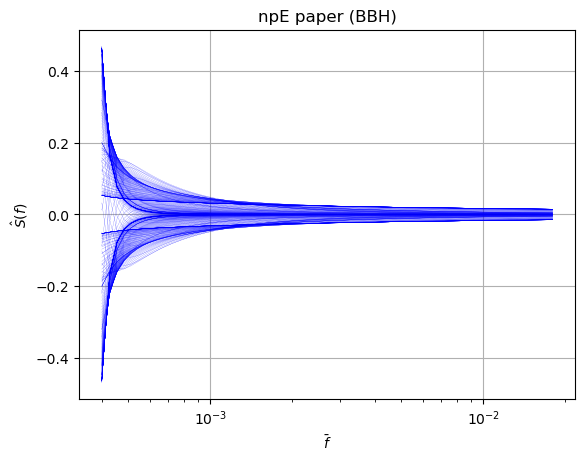

In [7]:
plot_dephasing(example_network_path, network_type='BBH', title='npE paper (BBH)')

z1:  (360,)
z2:  (360,)


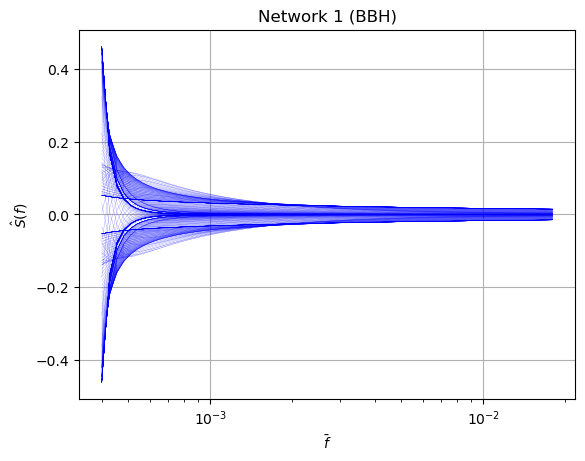

In [8]:
plot_dephasing(BBH_network_path, network_type='BBH', title='Network 1 (BBH)')

z1:  (360,)
z2:  (360,)


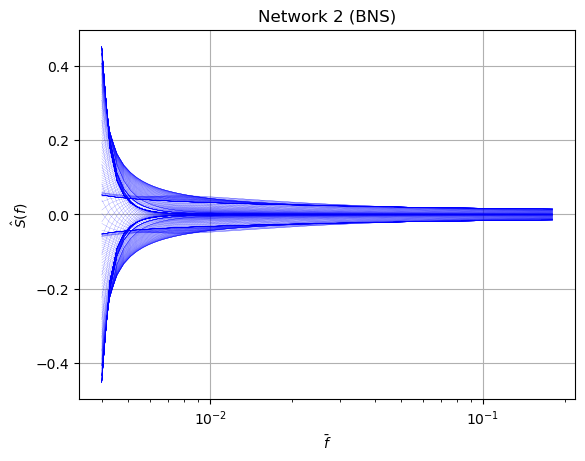

In [9]:
plot_dephasing(BNS_network_path, network_type='BNS', title='Network 2 (BNS)')

In [15]:
# Dataset loading imports
from data import DatasetManager, PhasingDataset
from train_network import DataLoader
# Latent space plotting imports
from utils.train import VAEEvaluationAgent, plot_latent_distrib
from utils.workflow import get_current_epoch_value
from train_network import vae_loss_fn, vae_diagnosis_fn


# Validation dataset
def get_val_dataloader(base_path=project_path, network_type='BBH'):
    return get_dataloader(base_path, network_type, subset='val')

def get_val_dataset(base_path=project_path, network_type='BBH'):
    return get_val_dataloader(base_path, network_type).dataset

# Train dataset
def get_train_dataloader(base_path=project_path, network_type='BBH'):
    return get_dataloader(base_path, network_type, subset='train')

def get_train_dataset(base_path=project_path, network_type='BBH'):
    return get_train_dataloader(base_path, network_type).dataset

# Test dataset
def get_test_dataloader(base_path=project_path, network_type='BBH'):
    return get_dataloader(base_path, network_type, subset='test')

def get_test_dataset(base_path=project_path, network_type='BBH'):
    return get_test_dataloader(base_path, network_type).dataset

# Function to import a dataset from a file
def get_dataloader(base_path=project_path, network_type='BBH', subset=None):
    if network_type == 'BNS':
        network_type_short = 'NS'
        dataset_filenames = [
            "ppe-minus13.pkl",
            "ppe-minus11.pkl",
            "ppe-minus9.pkl",
            "ppe-minus7.pkl",
            "ppe-minus5.pkl",
            "ppe-minus3.pkl",
            "ppe-minus1.pkl",
        ]
    else:
        network_type_short = 'BH'
        dataset_filenames = [
            "ppe-minus13.pkl",
            "ppe-minus11.pkl",
            "ppe-minus9.pkl",
            "ppe-minus7.pkl",
            "ppe-minus5.pkl",
            "ppe-minus3.pkl",
            "ppe-minus1.pkl",
        ]

    dataset_rootdir = os.path.expanduser(os.path.join(base_path, 'dataset_'+network_type_short))
    #print('Loading dataset from: ', dataset_rootdir)

    dataset_type = PhasingDataset
    dataset_n_ppe = 1
    dataset_norm_fac = {}
    dataset_sample_size = 0.25
    dataset_subset_split = [0.8, 0.1, 0.1]
    dataset_seed = 1234

    dataset_and_split = DatasetManager(
                dataset_filenames, root_dir=dataset_rootdir, 
                sample_size=dataset_sample_size, subset_split=dataset_subset_split, random_state=dataset_seed, 
                dataset_type=dataset_type, dataset_kwargs=dict(n_ppe=dataset_n_ppe, norm_fac=dataset_norm_fac))
        
    batch_size_train = 64
    batch_size_val = 1024
    batch_size_test = 64    # Assumption/guess
    batches_per_summary = 0.1

    dataset_train, dataset_val, dataset_test = dataset_and_split.subsets
    
    if subset is None:
        return (dataset_train, dataset_val, dataset_test)
    if subset in ['train', 'training']:
        data_loader_train = DataLoader(dataset_train, batch_size=batch_size_train, shuffle=True)
        return data_loader_train
    if subset in ['val', 'validation']:
        data_loader_val = DataLoader(dataset_val, batch_size=batch_size_val, shuffle=False)
        return data_loader_val
    if subset in ['test', 'testing', 'tune', 'tuning']:
        data_loader_test = DataLoader(dataset_test, batch_size=batch_size_test, shuffle=False)
        return data_loader_test

def plot_latent_space(network_path, base_path=project_path, network_type='BBH', use_final_kwargs=True):

    # Import network from file
    model, device, optimizer, scheduler = import_network(network_path, base_path)

    # State loss function and diagnosis function of interest
    loss_fn = vae_loss_fn
    diagnosis_fn = vae_diagnosis_fn

    # Use kwargs from shape function training
    if not use_final_kwargs:
        loss_kwargs = dict(
            kl_coeff=1e-6, 
            shape_coeff=1., scale_coeff=0., 
            recon_coeff=0., recon_scale_coeff=0.,
            with_mu=False, recon_use_mse=False, 
        )
        diagnosis_kwargs = dict(with_mu=False)
    else:
        # Use kwargs from scale function training
        loss_kwargs = dict(
            kl_coeff=0., 
            shape_coeff=0., scale_coeff=0., 
            recon_coeff=0., recon_scale_coeff=1.,
            with_mu=False, recon_use_mse=False, 
        )
        diagnosis_kwargs = dict(with_mu=False)

    # Define total epochs and current epoch (final)
    epochs_per_latent_plot = [(10, 1), (None, 10)]
    epochs_per_checkpoint = 50
    i_epoch = 100
        
    current_epochs_per_latent_plot = get_current_epoch_value(epochs_per_latent_plot, i_epoch)
    current_epochs_per_checkpoint = get_current_epoch_value(epochs_per_checkpoint, i_epoch)

    current_loss_kwargs = dict()
    for k,v in loss_kwargs.items():
        current_loss_kwargs[k] = get_current_epoch_value(v, i_epoch)

    print('Importing Datasets...')
    # Get training and validation sets used for network training
    data_loader_train = get_train_dataloader(base_path, network_type)
    data_loader_val = get_val_dataloader(base_path, network_type)

    #training_seed = None
    #torch.manual_seed(training_seed)

    # Latent space plot parameters
    npoints_for_latent_plot = int(1e2)
    npoints_for_generation = 16
 
    print('Constructing Agent...')
    # Establish VAE Evaluation Agent from loaded model and dataset
    agent = VAEEvaluationAgent(
                            model, loss_fn, diagnosis_fn, current_loss_kwargs, diagnosis_kwargs,
                            distrib_thin_fac=npoints_for_latent_plot/len(data_loader_val.dataset),
                            sample_size=npoints_for_generation)

    # Get hyperparameters at this epoch
    hparams = dict(
            lr=scheduler.get_last_lr()[0], 
            weight_decay=optimizer.defaults['weight_decay'],
            batch_size=data_loader_train.batch_size,
        )
    # hparams.update(agent.loss_fn_kwargs)
    for k, v in agent.loss_fn_kwargs.items():
        try: float(v)
        except TypeError: pass
        else: hparams[k] = v
    #log_str = "{} Epoch {}".format(datetime.now().strftime('%H:%M:%S'), i_epoch+1)
    #log_str += "\nHparams = {}".format(hparams)
    #print(log_str); sys.stdout.flush()

    print('Training agent...')
    # Agent train step
    if True:
        agent.train()
        for i_batch, data_batch in enumerate(data_loader_train):
            optimizer.zero_grad()
            loss = agent.add_batch(data_batch)
            if torch.isfinite(loss):
                loss.backward()
                optimizer.step()
            #if batches_per_summary > 0 and (i_batch+1) % batches_per_summary == 0:
                #loss_recent = agent.pop_recent_loss()
                #log_str = "  {:0.0f}%, interval loss = {:0.3e}".format(
                #                    100. * (i_batch+1) / len(data_loader_train), loss_recent)
                #print(log_str); sys.stdout.flush()
        scheduler.step()

        #loss_train = agent.report_loss()

    print('Evaluating Agent...')
    # Agent evaluation step
    agent.eval()
    for i_batch, data_batch in enumerate(data_loader_val):
        agent.add_batch(data_batch)
    #loss_val = agent.report_loss()
    #metrics = agent.report_metrics()

    print('Plotting Latent Space distribution...')
    # Plot latent space distribution
    distrib = {k: np.concatenate(agent._acc_distrib[k], axis=0) for k in agent._distrib_keys}
    fig_latent = plot_latent_distrib(distrib, plot_masked=False)

Importing Datasets...
Constructing Agent...
Training agent...
Evaluating Agent...
Plotting Latent Space distribution...


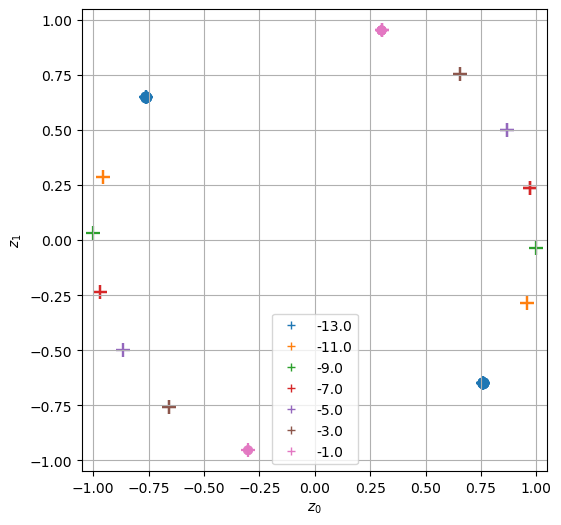

In [16]:
plot_latent_space(example_network_path)

Importing Datasets...
Constructing Agent...
Training agent...
Evaluating Agent...
Plotting Latent Space distribution...


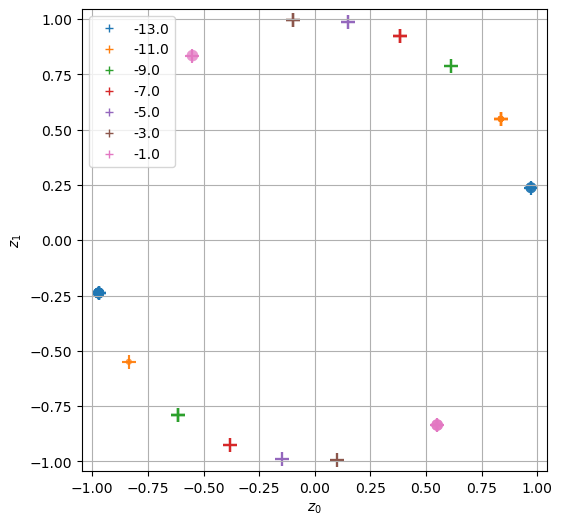

In [17]:
plot_latent_space(BBH_network_path)

Importing Datasets...
Constructing Agent...
Training agent...
Evaluating Agent...
Plotting Latent Space distribution...


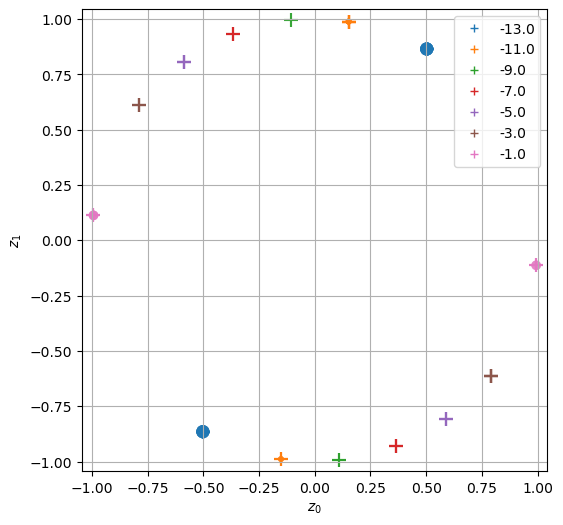

In [18]:
plot_latent_space(BNS_network_path)